In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
sys.path.append("..")
from src.utils import MoonsDataset
from src.models import MarginalDensityFlow
from functools import partial
from src.criticism import c2st, z_test
from src.data.toy_models import NormalNormal
from src.data.sir_model import SIRModel, SIModel, SIRSModel
from src.data.seir_model import SEIRModel
from scipy.special import logit

mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

# SIR Model

In [3]:
sir_dataset = SIRModel(beta=1.5, gamma=.5, prior_scale=[1, 1], N=100, T=10, observed_seed=9, n_sample=N, partial_obs=True,
                  mode="criticism", noise=noise)
train_data, val_data = random_split(sir_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


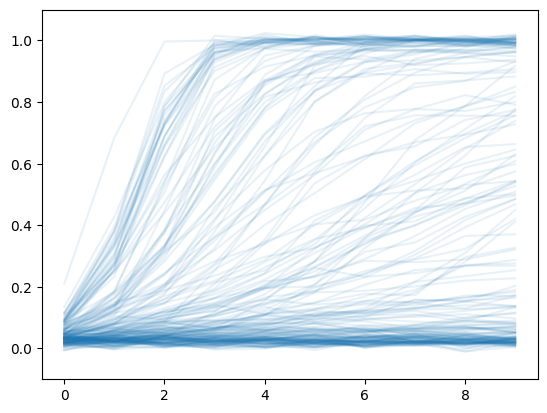

In [4]:
x_sample = sir_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

In [5]:
# optim = partial(torch.optim.AdamW, lr=0.0005)
# model = MarginalDensityFlow(10, 3, flow_type="NSF", optimizer=optim)
# callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
# trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
# trainer.fit(model, train_loader, val_loader)

In [6]:
# x_val, mll_val = trainer.predict(model, val_loader)[0]
# samples = model.sample(x_val.shape[0])
# c2st(x_val.squeeze(1), samples, noise_scale=.0)

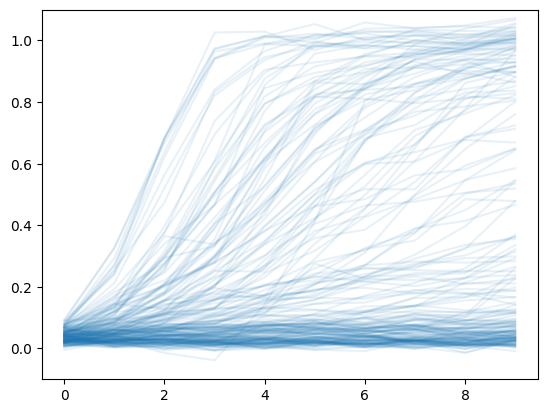

In [38]:
plt.plot(samples[:200, :].T, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

# SIR Constant Hazards

In [5]:
ch_dataset = SIRModel(beta=1.5, gamma=.5, prior_scale=[1, 1], N=100, T=10, observed_seed=9, n_sample=N, partial_obs=True,
                  mode="criticism", noise=noise, constant_hazard=7)

Simulating samples...


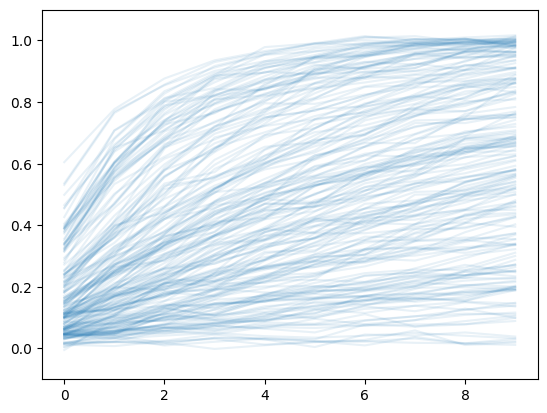

In [6]:
x_sample = ch_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

# SI Model

In [5]:
si_dataset = SIModel(beta=1.5, prior_scale=[1,], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise)

Simulating samples...


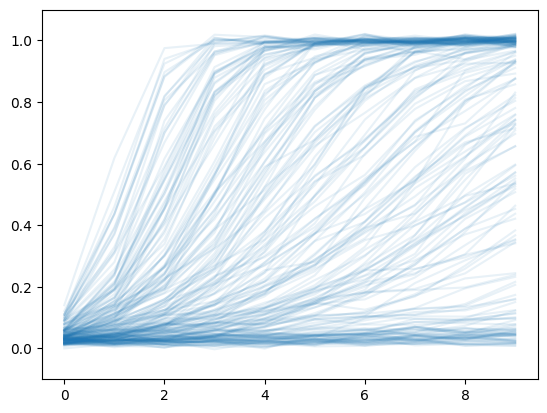

In [6]:
x_sample = si_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

# SIRS Model

In [3]:
sirs_dataset = SIRSModel(beta=1.5, gamma=1, delta=0.5, prior_scale=[1,1, 1], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise, partial_obs=True)

Simulating samples...


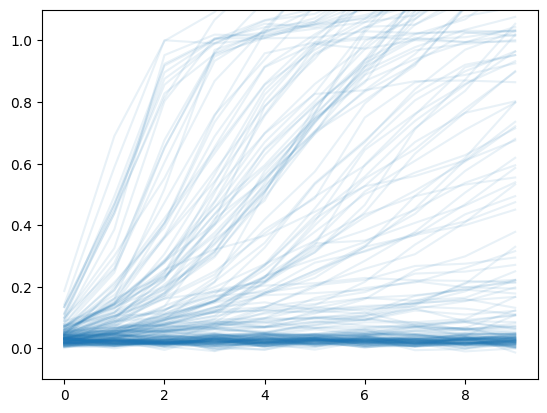

In [4]:
x_sample = sirs_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

# SEIR Model

In [3]:
seir_dataset = SEIRModel(beta=1.5, gamma=0.5, sigma=1, prior_scale=[1,1, 1], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise, partial_obs=True)

Simulating samples...


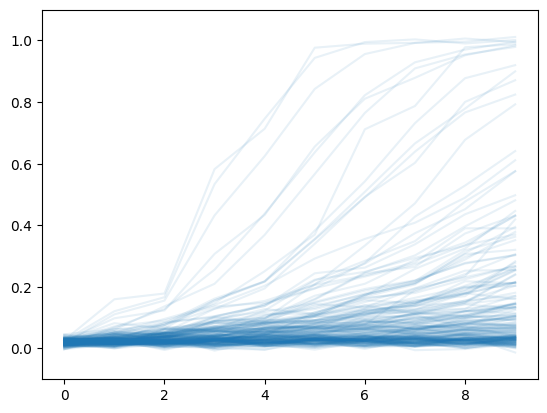

In [5]:
x_sample = seir_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()